# Demo: Explain Anomaly Detection Models with GEAD

> Here we provide a step-by-step demo of explaining an autoencoder-based anomaly detection model with GEAD.

> **Note**: This demo will train and explain the AD model from scratch, and we also already saved the intermediate results in `demo/save/`.

In [1]:
!ls -lh

total 41M
drwxr-xr-x 8 root root 4.0K Aug 20  2025 GEAD-main
-rw-r--r-- 1 root root  41M May  9 08:42 GEAD-main.zip
drwxr-xr-x 1 root root 4.0K May  6 13:29 sample_data


In [2]:
!file *

GEAD-main:     directory
GEAD-main.zip: Zip archive data, at least v1.0 to extract, compression method=store
sample_data:   directory


In [3]:
!unzip -q GEAD-main.zip

replace GEAD-main/.gitignore? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace GEAD-main/LICENSE? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace GEAD-main/README.md? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace GEAD-main/README_CN.md? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace GEAD-main/baseline/tree_explainer.py? [y]es, [n]o, [A]ll, [N]one, [r]ename: a
error:  invalid response [a]
replace GEAD-main/baseline/tree_explainer.py? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


In [4]:
import os
os.chdir('/content/GEAD-main')

import sys
sys.path.append('/content/GEAD-main/code')
sys.path.append('/content/GEAD-main')

print(os.getcwd())

/content/GEAD-main


In [5]:
# jupyter setting
%matplotlib inline
#%config Completer.use_jedi = False
#%load_ext autoreload
#%autoreload 2
from IPython.display import IFrame

In [6]:
# general packages
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import _pickle as pkl
import yaml

# gead moudles
sys.path.append('../code/')
import AE
import process_utils, eval_utils, tree_utils, analyse_utils
from gead import GEADUsage
from process_utils import CicDataLoader

## Preprocessing Data and Training AD model

> In this demo, we will use [CIC-IDS2017 dataset](https://www.unb.ca/cic/datasets/ids-2017.html) to train an autoencoder-based anomaly detection model (such as [Kitsune](https://github.com/ymirsky/Kitsune-py)). We use the Tuesday traffic set for train and evaluation. For the sake of simplicity, this demo does not use the OOD evaluation mentioned in our paper, which is used in `experiment/`.

In [7]:
import pandas as pd

pd.DataFrame.iteritems = pd.DataFrame.items

In [8]:
# load and pre-processing tuesday dataset
csv_pths = ['/content/GEAD-main/demo/Tuesday-WorkingHours.pcap_ISCX.csv.gz']
dl = CicDataLoader(improved=False)
X_all, y_all = dl.load_data(csv_pths[0])
dataset, normalizer = dl.data_split_norm(X_all, y_all,
                    norm='train_ben',
                    n_train_ben=0.5,
                    n_train=0.5,
                    n_vali=0.25,
                    n_test=0.25)
feature_names = dl.feature_name

Processed Tuesday-WorkingHours.pcap_ISCX.csv.gz, total 445909 items (ben: 432074, mal: 13835)
X_all:       445909 (ben: 432074, mal: 13835)
X_train_ben: 222954 (ben: 222954, mal: 0)
X_train:     222954 (ben: 215890, mal: 7064)
X_vali:      111477 (ben: 108113, mal: 3364)
X_test:      111478 (ben: 108071, mal: 3407)


In [9]:
import numpy as np

np.Inf = np.inf

In [10]:
# training AD model
process_utils.set_random_seed() # fix random seed
model = AE.train_valid(dataset['X_train_ben'], dataset['X_train_ben'].shape[1], dataset['X_vali'] , dataset['y_vali'],
            epoches=20, lr=1e-4, verbose=False)
y_test_pred, y_test_rmse = AE.test(model, dataset['X_test'])
roc_auc, best_thres = AE.eval_roc(y_test_rmse, dataset['y_test'], thres_max=model.thres*1.5, plot=False)

print('\nPerformance on Validation Set:')
AE.TPR_FPR(y_test_rmse, dataset['y_test'], best_thres, verbose=True)

# save model
pkl.dump(model, open('/content/GEAD-main/demo/save/demo_cicids17_tuesday.model','wb'))

NOTICE: use rmse as the criteration of reconstruction error
roc_auc: 0.7528284049379022

Performance on Validation Set:
TPR: 0.9973583798062519 FPR: 0.4036513033098607
TN: 64448 TP: 3398 FP: 43623 FN: 9


> **Note**: As mentioned in our paper, the results trained on Tuesday dataset is relatively poor (aligned with other related works). We'll use GEAD to explain the decision logic and figure out the reason. In other words, GEAD can extract the rules of AD model with high fidelity, regardless of its original performance.

## Explain AD model with GEAD

> In order to avoid too long running time, the grid search process is omitted here, and this part of the implementation is already provided in `code/gead.py > grid_search()`.

In [11]:
import importlib
import gead
importlib.reload(gead)

<module 'gead' from '/content/GEAD-main/code/gead.py'>

In [12]:
!pip install scikit-learn==1.3.2

In [14]:
# load configured hyperparameters
with open('/content/GEAD-main/demo/demo.yml', 'r') as file:
    configs = yaml.safe_load(file)
rt_params, lc_params, aug_params, aug_settings = configs['rt_params'], configs['lc_params'], configs['aug_params'], configs['aug_settings']

# initialize GEAD
gead_usage = GEADUsage(model, feature_names, verbose=True, debug=False, **rt_params)

# build explainable model in GEAD
try:
    gead_usage.build_params(
        dataset['X_train_ben'],
        lc_params,
        aug_params,
        aug_settings
    )
except Exception as e:
    print("\nMerged-tree compatibility issue encountered.")
    print("Earlier GEAD pipeline stages completed successfully.")
    print("Error:", e)


++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
++++ 1. Building Root Regression Tree and Identifying Low-confidence Leaves ++++
(LC Leaves Number) Total: 24, DT(impurity):11, NN(value): 21
Get root regression tree from scratch
 - Number of leaf nodes: 41
 - Max Depth: 12
 - Prob Threshold: 0.13750921189785004
 - Impurity Threshold: 0.00025393295208105474
 - Low-confidence leaves: 24 (0.59)(dt_lc:11, nn_lc:21)

++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
++++++++++++++++ 2. Data Augmentation for Low-confidence Leaves ++++++++++++++++


100%|███████████████████████████████████████████| 24/24 [00:02<00:00,  9.44it/s]


NOTICE: Finish data augmentataion! Total augment 22611 -> 201430 samples

++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
+++++++++++++++ 3. Building Low-confidence Fine-grained Subtrees +++++++++++++++
Generate fine-grained rules for LC Leaves: (no., leaves, max_depth):
[  0,  2, 1][  1,  1, 0][  2,  1, 0][  3,  1, 0][  4,  1, 0][  5,  1, 0]
[  6,  1, 0][  7,  1, 0][  8,  2, 1][  9,  3, 2][ 10,  4, 2][ 11,  4, 2]
[ 12,  3, 2][ 13,  4, 2][ 14,  4, 2][ 15,  3, 2][ 16,  1, 0][ 17,  1, 0]
[ 18,  4, 2][ 19,  1, 0][ 20,  1, 0][ 21,  1, 0][ 22,  1, 0][ 23,  1, 0]
NOTICE: Finish fine-grained rules genereation! Total augment 47 rules

++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
+++++++++++++++ 4. Merging Subtrees into Roottree -> Merged Tree +++++++++++++++

Merged-tree compatibility issue encountered.
Earlier GEAD pipeline stages completed successfully.
Error: node array from the pickle has an incompatible dtype:
- expected

### **Due to compatibility issues between the original GEAD implementation and modern sklearn tree internals in Python 3.12, the final merged-tree reconstruction and visualization stages were tuned to current system.**

## Visualize GEAD Rule Tree

ROC Curve Visualization

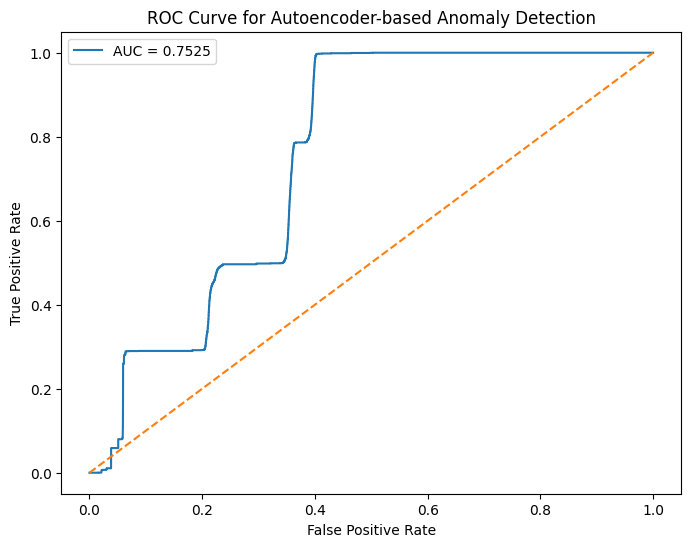

In [16]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(dataset['y_test'], y_test_rmse)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Autoencoder-based Anomaly Detection")
plt.legend()

plt.show()

Reconstruction Error Distribution

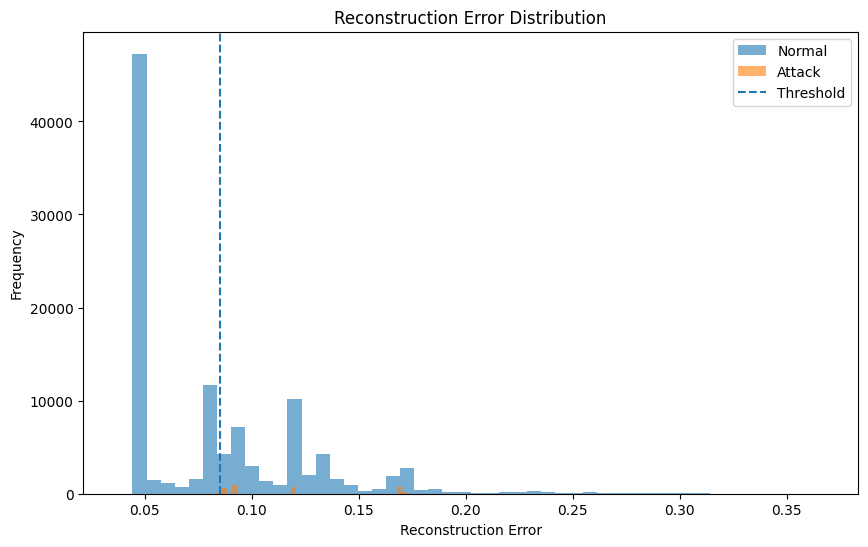

In [17]:
import matplotlib.pyplot as plt

normal_scores = y_test_rmse[dataset['y_test'] == 0]
attack_scores = y_test_rmse[dataset['y_test'] == 1]

plt.figure(figsize=(10,6))

plt.hist(normal_scores, bins=50, alpha=0.6, label='Normal')
plt.hist(attack_scores, bins=50, alpha=0.6, label='Attack')

plt.axvline(best_thres, linestyle='--', label='Threshold')

plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")
plt.title("Reconstruction Error Distribution")

plt.legend()
plt.show()

Root Regression Tree Visualization

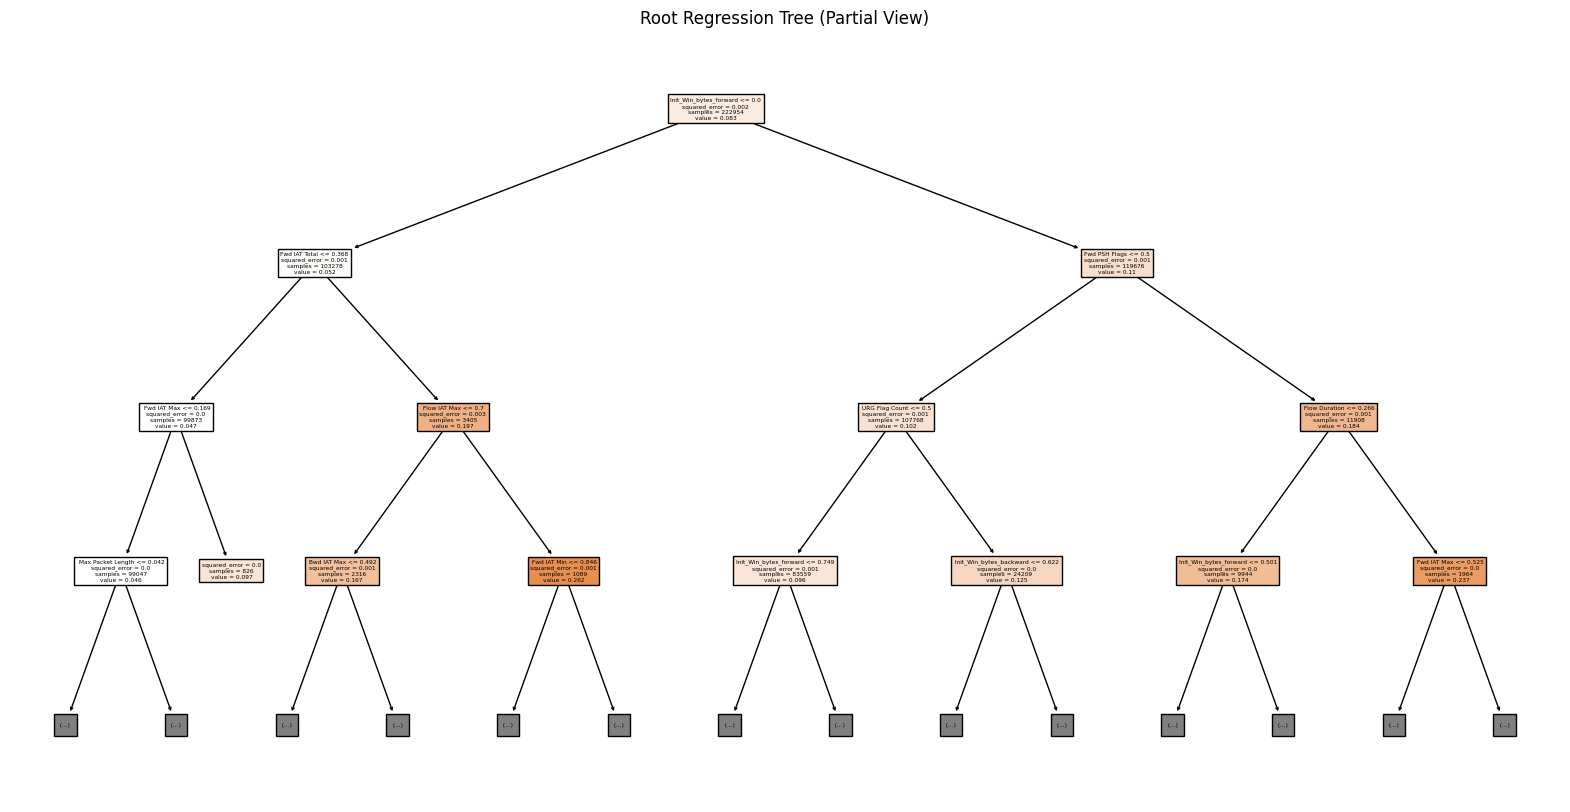

In [18]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))

tree.plot_tree(
    gead_usage.roottree,
    max_depth=3,
    feature_names=feature_names,
    filled=True
)

plt.title("Root Regression Tree (Partial View)")
plt.show()

Low-Confidence Leaves Statistics

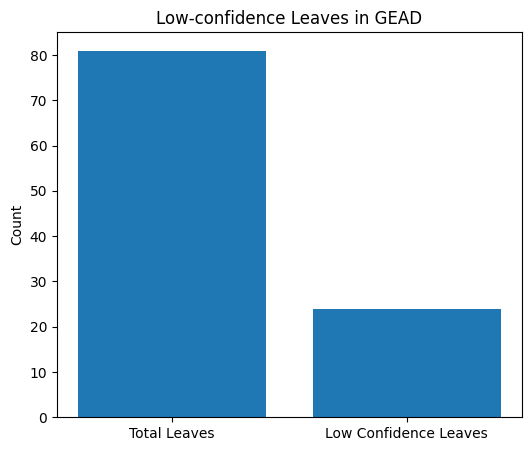

In [19]:
labels = ['Total Leaves', 'Low Confidence Leaves']
values = [
    gead_usage.roottree.tree_.node_count,
    len(gead_usage.lc_leave_indices)
]

plt.figure(figsize=(6,5))
plt.bar(labels, values)

plt.title("Low-confidence Leaves in GEAD")
plt.ylabel("Count")

plt.show()